In [1]:
using Pkg
Pkg.activate("../")
include("../scripts/CopepodsNN.jl")
include("../scripts/param.jl")
using NCDatasets
using Dates
using Glob
using DIVAnd
using GeoDatasets
using Makie
using CairoMakie
using GeoMakie
include("../scripts/param.jl")
doplot = true
coastline = GeoMakie.coastlines(10);
using JupyterFormatter
enable_autoformat()

  Activating project at `/media/ctroupin/T7Shield/Projects/EMODnet/EMODnet-Biology/EMODnet-Biology-Interpolation-NN-Copepods`


1-element Vector{Function}:
 format_current_cell (generic function with 1 method)

In [7]:
outputdir_optim = joinpath(outputdir, "param_optim/")
isdir(outputdir_optim)
expdirlist = filter(x -> isdir(joinpath(outputdir_optim, x)), readdir(outputdir_optim))

2-element Vector{String}:
 "20260316T150211"
 "20260316T150424"

In [13]:
bathyfile = joinpath(auxdatadir, "gebco_30sec_16.nc")
CopepodsNN.download_check(bathyfile, CopepodsNN.covariable_urls["gebco_30sec_16"])
_, _, mask = DIVAnd.load_mask(bathyfile, true, longrid, latgrid, 0.0);

[ Info: File ../data/aux_data/gebco_30sec_16.nc already downloaded


(-35.0:1.0:14.0, 37.0:1.0:72.0, Bool[1 1 … 0 0; 1 1 … 0 0; … ; 1 0 … 1 1; 1 0 … 1 1])

In [8]:
date2plot = Date(2008, 5, 1)
timeindex = findfirst(
    (Dates.month.(fielddates_monthly) .== Dates.month(date2plot)) .&
    (Dates.year.(fielddates_monthly) .== Dates.year(date2plot)),
)

605

In [74]:
function get_field(outputfile::AbstractString, timeindex::Int64 = 1)
    ds = NCDataset(outputfile)
    field2plot = coalesce.(ds["Small_copepods"][:, :, timeindex], NaN)
    RMS = ds.attrib["RMSE"]
    RMS = round(RMS, digits = 3)
    close(ds)
    return field2plot, RMS
end

get_field (generic function with 2 methods)

[ Info: 20260316T150211


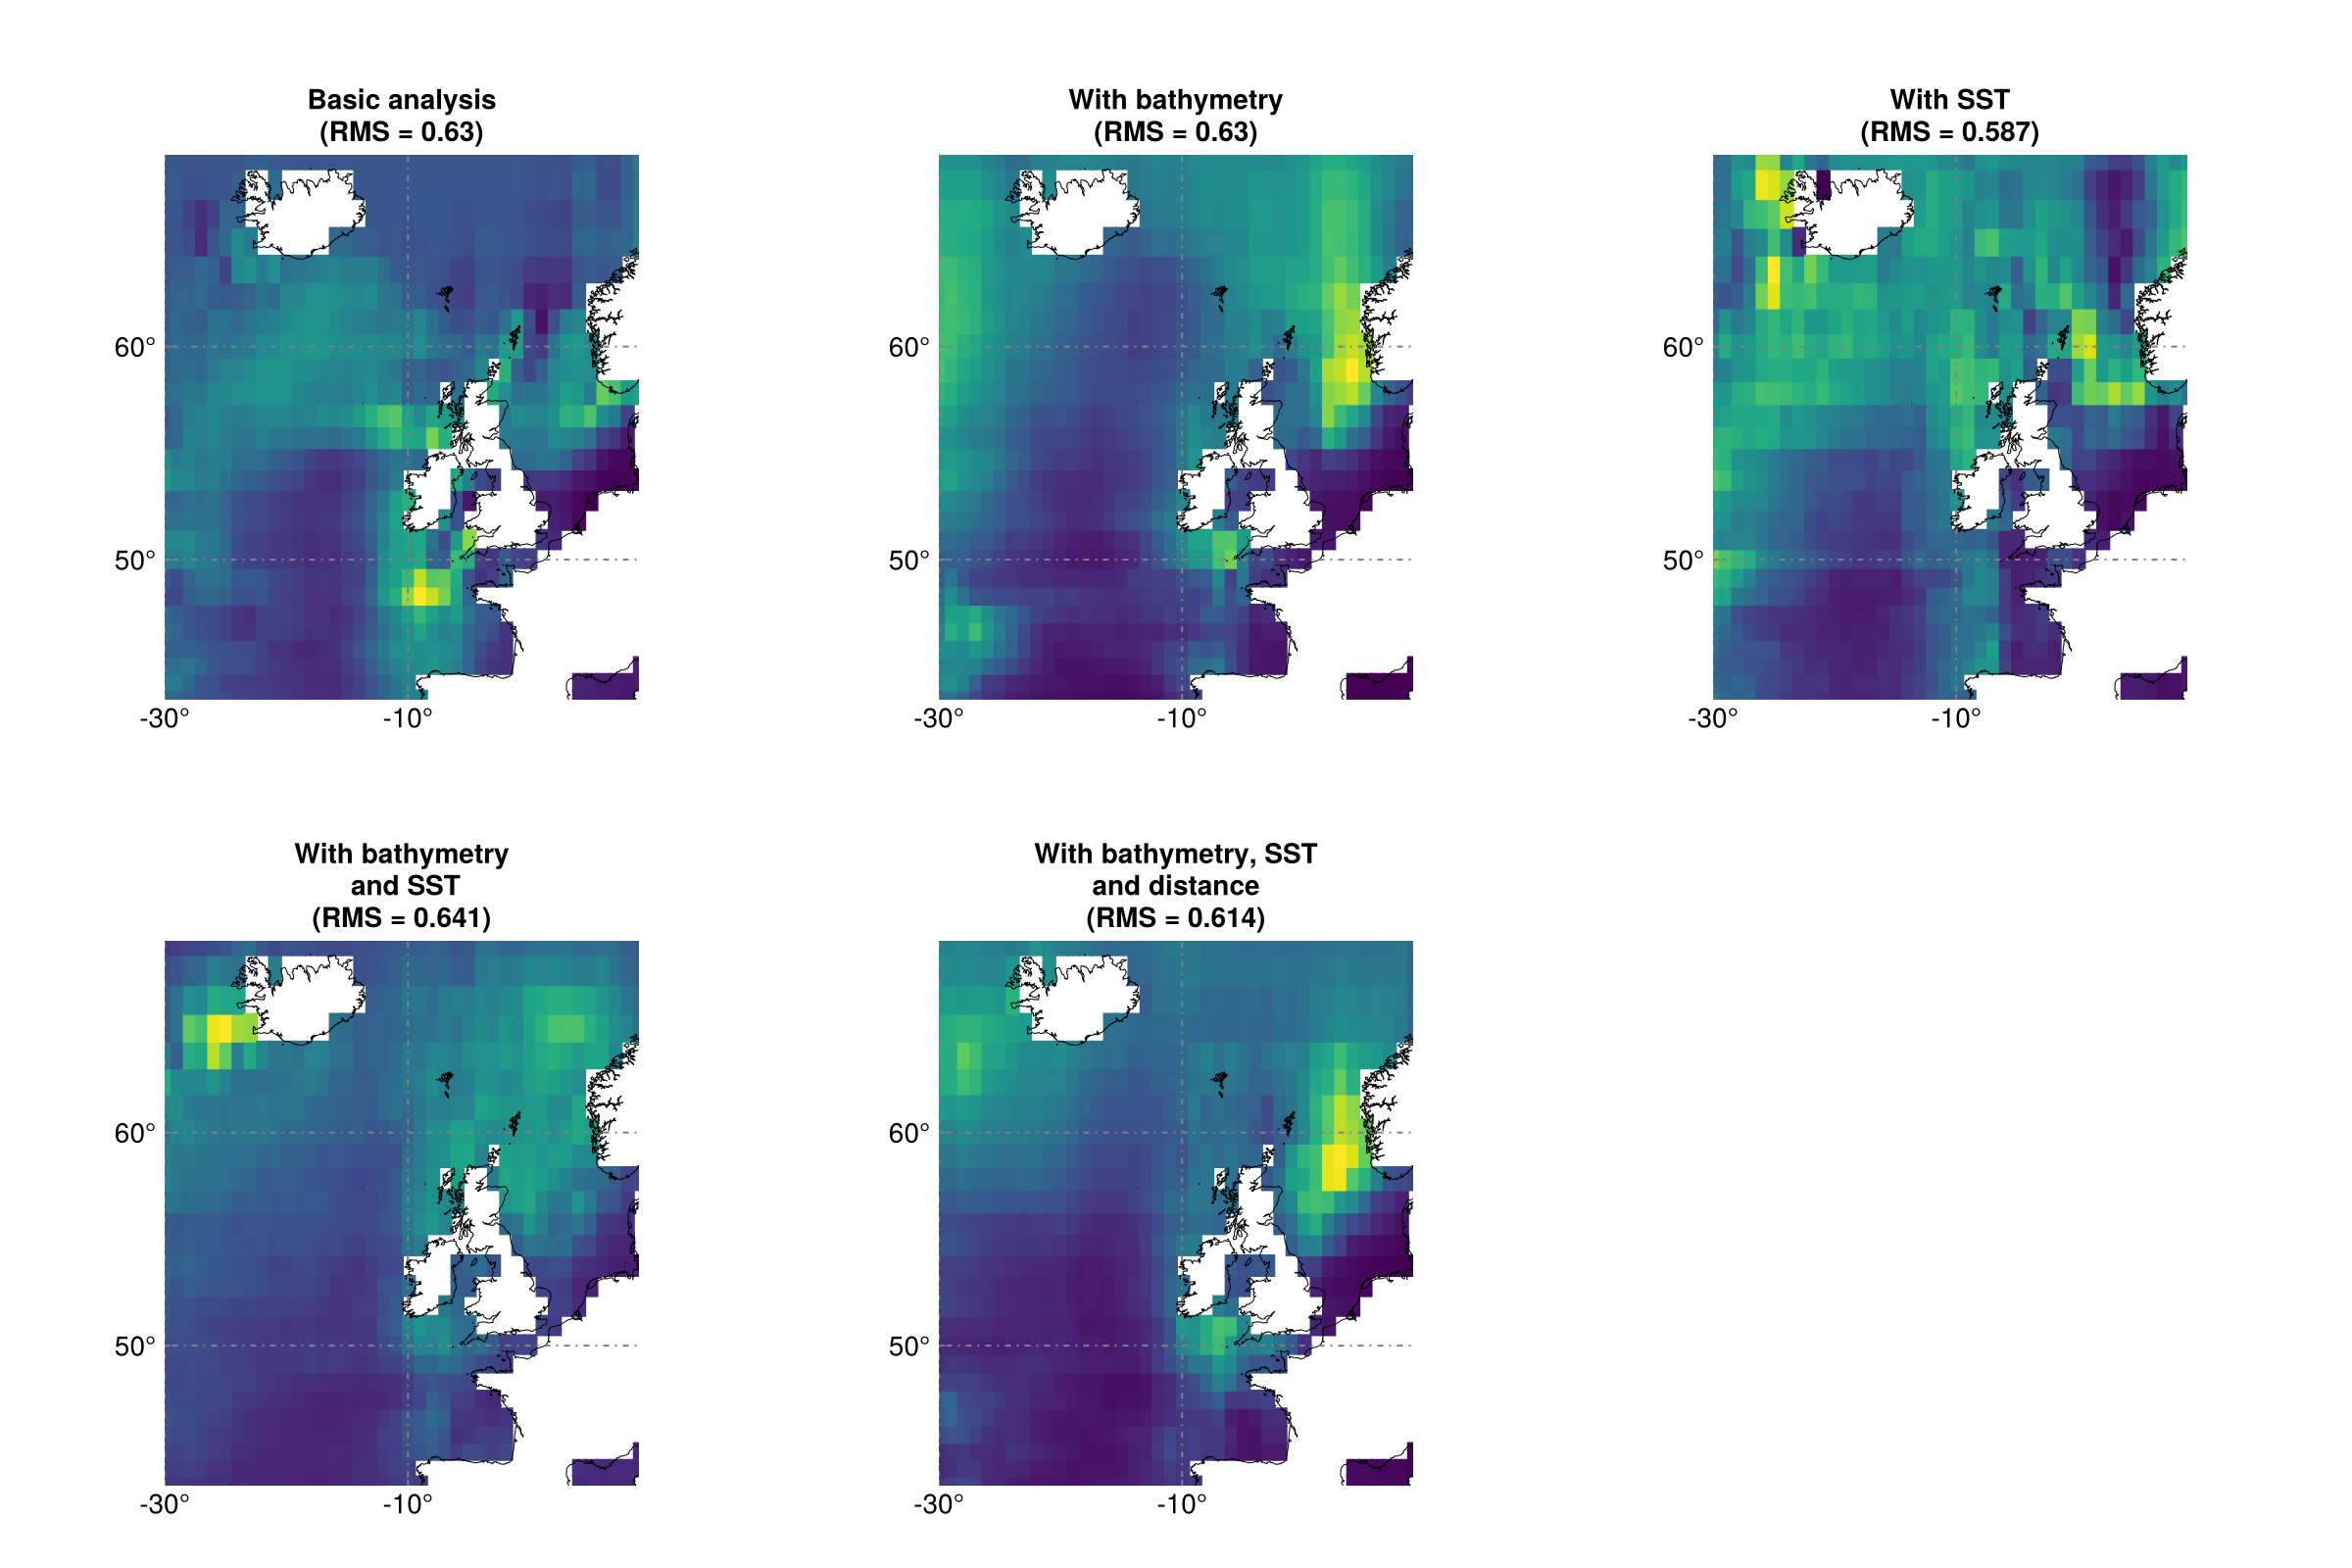

In [77]:
for expdir in expdirlist[1:1]
    @info(expdir)
    resfilelist = filter(
        x -> isfile(joinpath(outputdir_optim, expdir, x)),
        readdir(joinpath(outputdir_optim, expdir)),
    )


    fig = Figure(size = (1200, 800))

    field2plot, RMS = get_field(
        joinpath(outputdir_optim, expdir, "smallcopepods_20260316T150211.nc"),
        timeindex,
    )

    ga1 = CopepodsNN.create_geoaxis(
        fig,
        ii = 1,
        jj = 1,
        title = "Basic analysis\n(RMS = $(RMS))",
        domain = domain,
    )

    field2plot[.!mask] .= NaN
    heatmap!(ga1, longrid, latgrid, field2plot)
    lines!(ga1, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)

    ga2 = CopepodsNN.create_geoaxis(
        fig,
        ii = 1,
        jj = 2,
        title = "With bathymetry\n(RMS = $(RMS))",
        domain = domain,
    )
    field2plot, RMS = get_field(
        joinpath(outputdir_optim, expdir, "smallcopepods_20260316T150211_bathy.nc"),
        timeindex,
    )
    field2plot[.!mask] .= NaN
    heatmap!(ga2, longrid, latgrid, field2plot)
    lines!(ga2, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)

    ga3 = CopepodsNN.create_geoaxis(
        fig,
        ii = 1,
        jj = 3,
        title = "With SST\n(RMS = $(RMS))",
        domain = domain,
    )
    field2plot, RMS = get_field(
        joinpath(outputdir_optim, expdirlist[1], "smallcopepods_20260316T150211_sst.nc"),
        timeindex,
    )
    field2plot[.!mask] .= NaN
    heatmap!(ga3, longrid, latgrid, field2plot)
    lines!(ga3, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)

    ga4 = CopepodsNN.create_geoaxis(
        fig,
        ii = 2,
        jj = 1,
        title = "With bathymetry\n and SST\n(RMS = $(RMS))",
        domain = domain,
    )
    field2plot, RMS = get_field(
        joinpath(outputdir_optim, expdir, "smallcopepods_20260316T150211_bathy_sst.nc"),
        timeindex,
    )
    field2plot[.!mask] .= NaN
    heatmap!(ga4, longrid, latgrid, field2plot)
    lines!(ga4, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)

    ga5 = CopepodsNN.create_geoaxis(
        fig,
        ii = 2,
        jj = 2,
        title = "With bathymetry, SST\nand distance\n(RMS = $(RMS))",
        domain = domain,
    )
    field2plot, RMS = get_field(
        joinpath(
            outputdir_optim,
            expdir,
            "smallcopepods_20260316T150211_bathy_sst_coast.nc",
        ),
        timeindex,
    )
    field2plot[.!mask] .= NaN
    heatmap!(ga5, longrid, latgrid, field2plot)
    lines!(ga5, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)

    display(fig)

end